Loading required package: nnet



2D GRID LINEAR MODEL USING optim()
Model: y = w0 + w1*x1 + w2*x2 + e
Noise: e ~ N(0, |y_ij|)
Total raw points: 100 

Generated 200 experiments
Generated 400 experiments
Generated 600 experiments
Generated 800 experiments
Generated 1000 experiments
Generated 1200 experiments
Generated 1400 experiments
Generated 1600 experiments
Generated 1800 experiments
Generated 2000 experiments
Total experiments built: 2000 

Total meta rows built: 2000 

Summary of true k*:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   18.00   31.00   35.86   48.00  156.00 


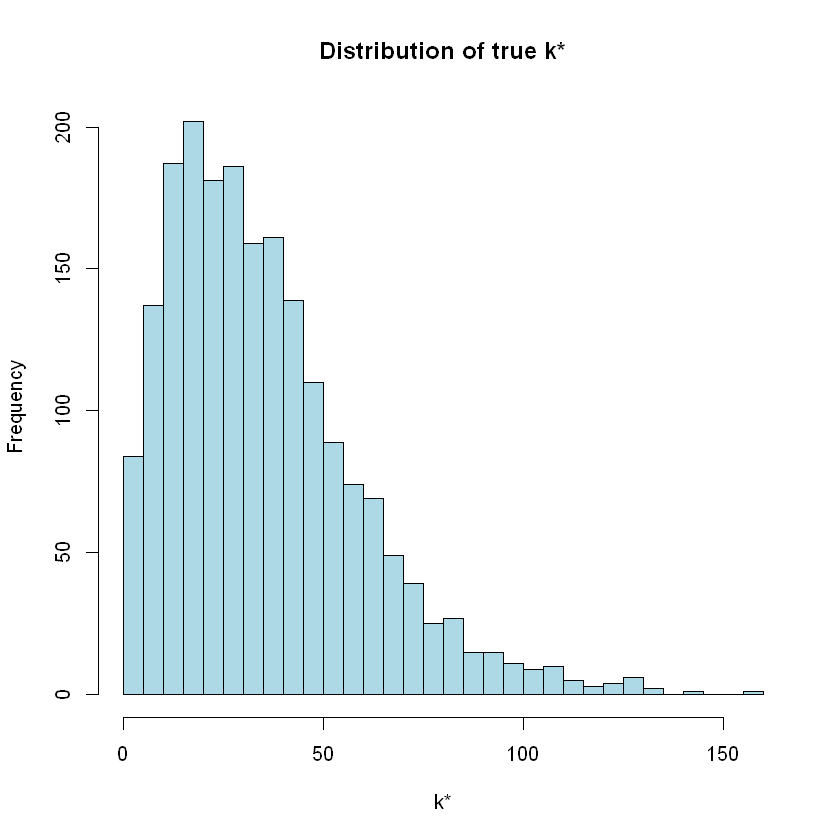

Meta-train rows: 1600 
Meta-test rows: 400 

Mean CV RMSE raw: 12.09966 
Mean CV RMSE int: 12.05413 

Final Test RMSE raw: 12.63466 
Final Test RMSE int: 12.56244 
Final Test MAE int: 7.775 


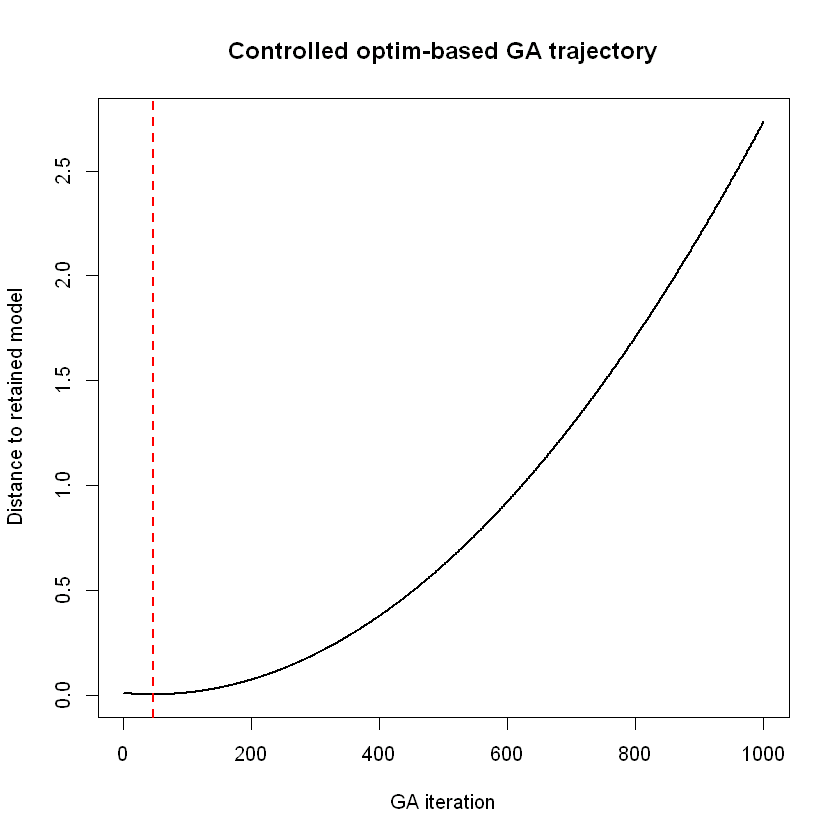

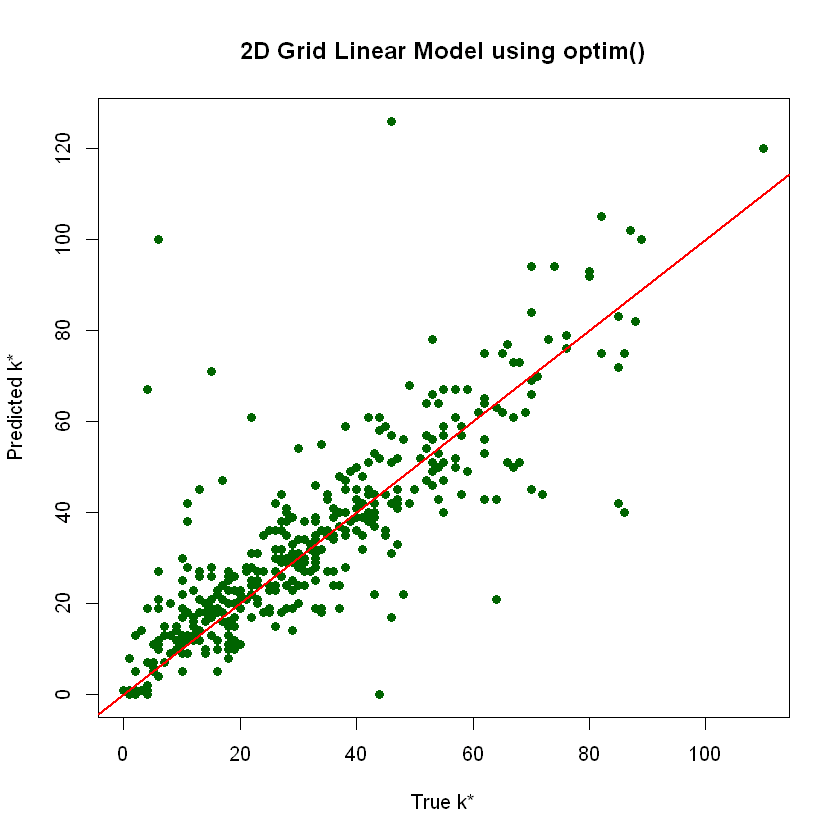

In [1]:
# 2D GRID LINEAR MODEL USING optim()
#
# y = w0 + w1*x1 + w2*x2 + e
# e ~ N(0, |y_ij|)
#
# Controlled GA:
# optim() + L-BFGS-B
# step_size = 0.001

set.seed(42)

if (!require(nnet)) {
  install.packages("nnet", repos = "https://cloud.r-project.org")
}
library(nnet)

# Simulate 2D grid linear Gaussian model

simulate_grid_linear_gaussian_yij <- function(
    grid_size = 10,
    w0_true = 2,
    w1_true = 1.5,
    w2_true = -1,
    min_sd = 0.001,
    seed = NULL
) {
  if (!is.null(seed)) set.seed(seed)

  x1_vals <- seq(-1, 1, length.out = grid_size)
  x2_vals <- seq(-1, 1, length.out = grid_size)

  grid_df <- expand.grid(
    x1 = x1_vals,
    x2 = x2_vals
  )

  y_true <- w0_true +
    w1_true * grid_df$x1 +
    w2_true * grid_df$x2

  sigma_ij <- sqrt(pmax(abs(y_true), min_sd))

  eps <- rnorm(
    n = nrow(grid_df),
    mean = 0,
    sd = sigma_ij
  )

  y_obs <- y_true + eps

  data.frame(
    x1 = grid_df$x1,
    x2 = grid_df$x2,
    y = y_obs,
    y_true = y_true,
    sigma_ij = sigma_ij
  )
}

# Helpers

safe_sd <- function(x) {
  if (length(x) <= 1) return(0)
  s <- sd(x)
  if (is.na(s) || is.nan(s) || is.infinite(s)) return(0)
  s
}

standardize_xyz <- function(x1, x2, y) {
  x1_sd <- safe_sd(x1)
  x2_sd <- safe_sd(x2)
  y_sd  <- safe_sd(y)

  if (x1_sd == 0) x1_sd <- 1
  if (x2_sd == 0) x2_sd <- 1
  if (y_sd == 0)  y_sd <- 1

  list(
    x1 = (x1 - mean(x1)) / x1_sd,
    x2 = (x2 - mean(x2)) / x2_sd,
    y  = (y  - mean(y))  / y_sd
  )
}

make_design_matrix <- function(x1, x2) {
  cbind(
    intercept = 1,
    x1 = x1,
    x2 = x2
  )
}


# Loss function

mse_loss <- function(theta, Phi, Y) {
  pred <- as.vector(Phi %*% theta)
  mean((Y - pred)^2)
}

# GD using optim()

fit_optim_gd <- function(Phi, Y, theta_init = NULL, maxit = 1000) {
  if (is.null(theta_init)) {
    theta_init <- rep(0, ncol(Phi))
  }

  fit <- optim(
    par = theta_init,
    fn = mse_loss,
    Phi = Phi,
    Y = Y,
    method = "BFGS",
    control = list(maxit = maxit)
  )

  fit$par
}

# Controlled GA using optim()
# Minimise negative deleted loss = maximise deleted loss
ga_trajectory_optim <- function(
    theta_start,
    Phi_del,
    Y_del,
    T_GA = 1000,
    step_size = 0.001
) {
  theta_now <- theta_start

  traj_theta <- matrix(
    NA,
    nrow = T_GA + 1,
    ncol = length(theta_start)
  )

  traj_theta[1, ] <- theta_now

  for (k in 1:T_GA) {
    fit <- optim(
      par = theta_now,
      fn = function(theta) {
        -mse_loss(theta, Phi_del, Y_del)
      },
      method = "L-BFGS-B",
      lower = theta_now - step_size,
      upper = theta_now + step_size,
      control = list(maxit = 1)
    )

    theta_now <- fit$par
    traj_theta[k + 1, ] <- theta_now
  }

  traj_theta
}

# One deletion experiment

one_experiment_deleted_retained <- function(
    df,
    p_del,
    T_GD = 1000,
    T_GA = 1000,
    step_size = 0.001
) {
  x1 <- df$x1
  x2 <- df$x2
  y  <- df$y

  n <- nrow(df)

  K_del <- max(1, floor(n * p_del))
  K_del <- min(K_del, n - 1)

  st <- standardize_xyz(x1, x2, y)

  X1 <- st$x1
  X2 <- st$x2
  Y  <- st$y

  Phi <- make_design_matrix(X1, X2)

  theta_full <- fit_optim_gd(
    Phi = Phi,
    Y = Y,
    maxit = T_GD
  )

  del_idx <- sample(1:n, K_del, replace = FALSE)

  del_mask <- rep(FALSE, n)
  del_mask[del_idx] <- TRUE

  Phi_del <- Phi[del_mask, , drop = FALSE]
  Y_del <- Y[del_mask]

  Phi_ret <- Phi[!del_mask, , drop = FALSE]
  Y_ret <- Y[!del_mask]

  theta_ret <- fit_optim_gd(
    Phi = Phi_ret,
    Y = Y_ret,
    maxit = T_GD
  )

  traj_theta <- ga_trajectory_optim(
    theta_start = theta_full,
    Phi_del = Phi_del,
    Y_del = Y_del,
    T_GA = T_GA,
    step_size = step_size
  )

  dists <- rowSums(
    sweep(traj_theta, 2, theta_ret, "-")^2
  )

  k_star <- which.min(dists) - 1

  deleted_points <- as.matrix(
    df[del_mask, c("x1", "x2", "y")]
  )

  retained_points <- as.matrix(
    df[!del_mask, c("x1", "x2", "y")]
  )

  list(
    deleted_points = deleted_points,
    retained_points = retained_points,
    k_star = as.numeric(k_star),
    K_del = K_del,
    p_del = p_del,
    dists = dists,
    theta_full = theta_full,
    theta_ret = theta_ret,
    traj_theta = traj_theta
  )
}

# Build many experiments

build_experiment_dataset <- function(
    df,
    n_experiments = 2000,
    p_min = 0.01,
    p_max = 0.50,
    T_GD = 1000,
    T_GA = 1000,
    step_size = 0.001
) {
  samples <- vector("list", n_experiments)

  for (i in 1:n_experiments) {
    p_now <- runif(1, min = p_min, max = p_max)

    samples[[i]] <- one_experiment_deleted_retained(
      df = df,
      p_del = p_now,
      T_GD = T_GD,
      T_GA = T_GA,
      step_size = step_size
    )

    if (i %% 200 == 0) {
      cat("Generated", i, "experiments\n")
    }
  }

  samples
}

# Embedding + pooling

embed_and_pool <- function(points_mat, W, b) {
  if (nrow(points_mat) == 0) {
    stop("Empty set encountered.")
  }

  embedded <- sweep(
    points_mat %*% W,
    2,
    b,
    "+"
  )

  mean_pool <- colMeans(embedded)
  max_pool  <- apply(embedded, 2, max)
  min_pool  <- apply(embedded, 2, min)
  sd_pool   <- apply(embedded, 2, safe_sd)

  c(mean_pool, max_pool, min_pool, sd_pool)
}

build_pooled_feature_table <- function(
    samples,
    embed_dim = 16,
    total_raw_n = 100,
    seed = 42
) {
  set.seed(seed)

  W <- matrix(
    rnorm(3 * embed_dim, mean = 0, sd = 0.3),
    nrow = 3,
    ncol = embed_dim
  )

  b <- rnorm(embed_dim, mean = 0, sd = 0.05)

  rows <- vector("list", length(samples))

  for (i in seq_along(samples)) {
    s <- samples[[i]]

    del_vec <- embed_and_pool(s$deleted_points, W, b)
    ret_vec <- embed_and_pool(s$retained_points, W, b)

    row_i <- as.data.frame(as.list(c(del_vec, ret_vec)))

    names(row_i) <- c(
      paste0("del_mean_emb_", 1:embed_dim),
      paste0("del_max_emb_",  1:embed_dim),
      paste0("del_min_emb_",  1:embed_dim),
      paste0("del_sd_emb_",   1:embed_dim),

      paste0("ret_mean_emb_", 1:embed_dim),
      paste0("ret_max_emb_",  1:embed_dim),
      paste0("ret_min_emb_",  1:embed_dim),
      paste0("ret_sd_emb_",   1:embed_dim)
    )

    row_i$p_del <- s$p_del
    row_i$K_del <- s$K_del
    row_i$del_fraction <- s$K_del / total_raw_n
    row_i$target_k_star <- s$k_star

    rows[[i]] <- row_i
  }

  out <- do.call(rbind, rows)
  out <- na.omit(out)

  out
}

# Scale features

scale_features_train <- function(df_features) {
  means <- sapply(df_features, mean)
  sds <- sapply(df_features, safe_sd)

  sds[sds == 0] <- 1

  scaled <- as.data.frame(
    scale(df_features, center = means, scale = sds)
  )

  scaled[is.na(scaled)] <- 0

  list(
    data = scaled,
    means = means,
    sds = sds
  )
}

scale_features_apply <- function(df_features, means, sds) {
  sds[sds == 0] <- 1

  scaled <- as.data.frame(
    scale(df_features, center = means, scale = sds)
  )

  scaled[is.na(scaled)] <- 0

  scaled
}

# Best MLP

fit_best_nnet <- function(
    x_train_sc,
    y_train,
    hidden_units = 6,
    decay = 0.001,
    maxit = 1000,
    maxnwts = 15000,
    n_repeats = 5,
    seed = 42
) {
  best_fit <- NULL
  best_sse <- Inf

  for (r in 1:n_repeats) {
    set.seed(seed + r)

    fit_try <- try(
      nnet(
        x = x_train_sc,
        y = y_train,
        size = hidden_units,
        linout = TRUE,
        decay = decay,
        maxit = maxit,
        trace = FALSE,
        MaxNWts = maxnwts
      ),
      silent = TRUE
    )

    if (inherits(fit_try, "try-error")) next

    pred_train <- as.numeric(predict(fit_try, x_train_sc))
    sse <- sum((pred_train - y_train)^2)

    if (is.finite(sse) && sse < best_sse) {
      best_sse <- sse
      best_fit <- fit_try
    }
  }

  if (is.null(best_fit)) {
    stop("All MLP fits failed.")
  }

  best_fit
}

postprocess_khat <- function(pred_scaled, target_mean, target_sd, T_GA) {
  pred_raw <- pred_scaled * target_sd + target_mean
  pred_int <- round(pred_raw)
  pred_int <- pmax(0, pmin(T_GA, pred_int))

  list(
    pred_raw = pred_raw,
    pred_int = pred_int
  )
}

cv_mlp_regression <- function(
    meta_train,
    k_folds = 5,
    hidden_units = 6,
    decay = 0.001,
    maxit = 1000,
    n_repeats = 5,
    T_GA = 1000,
    seed = 42
) {
  set.seed(seed)

  n <- nrow(meta_train)
  fold_id <- sample(rep(1:k_folds, length.out = n))

  rmse_raw_vec <- c()
  rmse_int_vec <- c()

  feature_names <- setdiff(names(meta_train), "target_k_star")

  for (fold in 1:k_folds) {
    train_fold <- meta_train[fold_id != fold, ]
    valid_fold <- meta_train[fold_id == fold, ]

    x_train <- train_fold[, feature_names, drop = FALSE]
    y_train_raw <- train_fold$target_k_star

    x_valid <- valid_fold[, feature_names, drop = FALSE]
    y_valid <- valid_fold$target_k_star

    y_mean_fold <- mean(y_train_raw)
    y_sd_fold <- safe_sd(y_train_raw)

    if (y_sd_fold == 0) y_sd_fold <- 1

    y_train <- (y_train_raw - y_mean_fold) / y_sd_fold

    sc <- scale_features_train(x_train)

    x_train_sc <- as.matrix(sc$data)
    x_valid_sc <- as.matrix(
      scale_features_apply(x_valid, sc$means, sc$sds)
    )

    mlp_fit <- fit_best_nnet(
      x_train_sc = x_train_sc,
      y_train = y_train,
      hidden_units = hidden_units,
      decay = decay,
      maxit = maxit,
      n_repeats = n_repeats,
      seed = seed + 100 * fold
    )

    pred_scaled <- as.numeric(predict(mlp_fit, x_valid_sc))

    pred_out <- postprocess_khat(
      pred_scaled = pred_scaled,
      target_mean = y_mean_fold,
      target_sd = y_sd_fold,
      T_GA = T_GA
    )

    rmse_raw <- sqrt(mean((pred_out$pred_raw - y_valid)^2))
    rmse_int <- sqrt(mean((pred_out$pred_int - y_valid)^2))

    rmse_raw_vec <- c(rmse_raw_vec, rmse_raw)
    rmse_int_vec <- c(rmse_int_vec, rmse_int)
  }

  list(
    mean_rmse_raw = mean(rmse_raw_vec),
    mean_rmse_int = mean(rmse_int_vec)
  )
}

train_and_test_mlp <- function(
    meta_train,
    meta_test,
    hidden_units = 6,
    decay = 0.001,
    maxit = 1000,
    n_repeats = 5,
    T_GA = 1000,
    seed = 42
) {
  feature_names <- setdiff(names(meta_train), "target_k_star")

  target_mean <- mean(meta_train$target_k_star)
  target_sd <- safe_sd(meta_train$target_k_star)

  if (target_sd == 0) target_sd <- 1

  x_train <- meta_train[, feature_names, drop = FALSE]
  x_test  <- meta_test[, feature_names, drop = FALSE]

  y_train_scaled <- (meta_train$target_k_star - target_mean) / target_sd
  y_test <- meta_test$target_k_star

  sc <- scale_features_train(x_train)

  x_train_sc <- as.matrix(sc$data)
  x_test_sc <- as.matrix(
    scale_features_apply(x_test, sc$means, sc$sds)
  )

  final_mlp <- fit_best_nnet(
    x_train_sc = x_train_sc,
    y_train = y_train_scaled,
    hidden_units = hidden_units,
    decay = decay,
    maxit = maxit,
    n_repeats = n_repeats,
    seed = seed
  )

  pred_scaled <- as.numeric(predict(final_mlp, x_test_sc))

  pred_out <- postprocess_khat(
    pred_scaled = pred_scaled,
    target_mean = target_mean,
    target_sd = target_sd,
    T_GA = T_GA
  )

  rmse_raw <- sqrt(mean((pred_out$pred_raw - y_test)^2))
  rmse_int <- sqrt(mean((pred_out$pred_int - y_test)^2))
  mae_int  <- mean(abs(pred_out$pred_int - y_test))

  list(
    y_test = y_test,
    pred_int = pred_out$pred_int,
    rmse_raw = rmse_raw,
    rmse_int = rmse_int,
    mae_int = mae_int
  )
}

# MAIN


base_df <- simulate_grid_linear_gaussian_yij(
  grid_size = 10,
  seed = 7
)

cat("2D GRID LINEAR MODEL USING optim()\n")
cat("Model: y = w0 + w1*x1 + w2*x2 + e\n")
cat("Noise: e ~ N(0, |y_ij|)\n")
cat("Total raw points:", nrow(base_df), "\n\n")

samples <- build_experiment_dataset(
  df = base_df,
  n_experiments = 2000,
  p_min = 0.01,
  p_max = 0.50,
  T_GD = 1000,
  T_GA = 1000,
  step_size = 0.001
)

cat("Total experiments built:", length(samples), "\n\n")

meta_all <- build_pooled_feature_table(
  samples = samples,
  embed_dim = 16,
  total_raw_n = nrow(base_df),
  seed = 42
)

cat("Total meta rows built:", nrow(meta_all), "\n\n")

cat("Summary of true k*:\n")
print(summary(meta_all$target_k_star))

hist(
  meta_all$target_k_star,
  breaks = 40,
  col = "lightblue",
  main = "Distribution of true k*",
  xlab = "k*"
)

plot(
  samples[[1]]$dists,
  type = "l",
  lwd = 2,
  xlab = "GA iteration",
  ylab = "Distance to retained model",
  main = "Controlled optim-based GA trajectory"
)

abline(
  v = samples[[1]]$k_star + 1,
  col = "red",
  lwd = 2,
  lty = 2
)

set.seed(42)

idx_meta_train <- sample(
  seq_len(nrow(meta_all)),
  size = floor(0.8 * nrow(meta_all))
)

meta_train <- meta_all[idx_meta_train, ]
meta_test <- meta_all[-idx_meta_train, ]

cat("Meta-train rows:", nrow(meta_train), "\n")
cat("Meta-test rows:", nrow(meta_test), "\n\n")

cv_res <- cv_mlp_regression(
  meta_train = meta_train,
  hidden_units = 6,
  T_GA = 1000
)

cat("Mean CV RMSE raw:", cv_res$mean_rmse_raw, "\n")
cat("Mean CV RMSE int:", cv_res$mean_rmse_int, "\n\n")

final_res <- train_and_test_mlp(
  meta_train = meta_train,
  meta_test = meta_test,
  hidden_units = 6,
  T_GA = 1000
)

cat("Final Test RMSE raw:", final_res$rmse_raw, "\n")
cat("Final Test RMSE int:", final_res$rmse_int, "\n")
cat("Final Test MAE int:", final_res$mae_int, "\n")

plot(
  final_res$y_test,
  final_res$pred_int,
  pch = 16,
  col = "darkgreen",
  xlab = "True k*",
  ylab = "Predicted k*",
  main = "2D Grid Linear Model using optim()"
)

abline(0, 1, col = "red", lwd = 2)